## Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, utils, optimizers
from tensorflow.keras.datasets import cifar10

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

2026-04-04 00:25:32.175407: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775262332.564860      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775262332.684658      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775262333.676040      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775262333.676090      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775262333.676093      24 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: True


## Loading Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

num_classes = 10
y_train_labels = y_train.copy().flatten()
y_train = utils.to_categorical(y_train, num_classes)
y_test = utils.to_categorical(y_test, num_classes)

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

print(f"Train: {x_train.shape}, Test: {x_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: (50000, 32, 32, 3), Test: (10000, 32, 32, 3)


# Conditional Generative Adversarial Network (CGAN)

### Hyperparameters

In [3]:
img_shape = (32, 32, 3)
latent_dim = 128
batch_size = 128
epochs = 100

## CGAN Architecture

### Generator

In [4]:
def build_generator(latent_dim, num_classes):
    # Noise input
    noise_input = layers.Input(shape=(latent_dim,))
    # Label input
    label_input = layers.Input(shape=(num_classes,))

    # Concatenate noise and label
    x = layers.Concatenate()([noise_input, label_input])

    # Project and reshape to 8x8x256
    x = layers.Dense(8 * 8 * 256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Reshape((8, 8, 256))(x)

    # Upsample to 8x8x128
    x = layers.Conv2DTranspose(128, 3, strides=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    # Upsample to 16x16x64
    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    # Upsample to 32x32x32
    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    # Output layer: 32x32x3
    output = layers.Conv2DTranspose(3, 3, strides=1, padding='same', activation='sigmoid')(x)

    model = models.Model([noise_input, label_input], output, name='Generator')
    return model

generator = build_generator(latent_dim, num_classes)
generator.summary()

I0000 00:00:1775262376.018345      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775262376.024319      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 138)       │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16384)     │  2,260,992 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 16384)     │     65,536 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 16384)     │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 8, 8, 256) │          0 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 8, 8, 128) │    294,912 │ reshape[0][0]     │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 128) │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 8, 8, 128) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 16, 16,    │     73,728 │ leaky_re_lu_1[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 32, 32,    │     18,432 │ leaky_re_lu_2[0]… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 32, 32, 3) │        867 │ leaky_re_lu_3[0]… │
│ (Conv2DTranspose)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 2,715,363 (10.36 MB)

 Trainable params: 2,682,147 (10.23 MB)

 Non-trainable params: 33,216 (129.75 KB)

### Discriminator

In [5]:
def build_discriminator(img_shape, num_classes):
    # Image input
    img_input = layers.Input(shape=img_shape)
    # Label input
    label_input = layers.Input(shape=(num_classes,))

    # Expand label to image dimensions and concatenate with image
    y = layers.Dense(np.prod(img_shape), activation='relu')(label_input)
    y = layers.Reshape(img_shape)(y)
    x = layers.Concatenate()([img_input, y])

    # Conv blocks (mirrors the CNN encoder style)
    x = layers.Conv2D(32, 3, strides=1, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(64, 3, strides=2, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, 3, strides=2, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, 3, strides=1, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128)(x)
    x = layers.LeakyReLU(0.2)(x)
    output = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model([img_input, label_input], output, name='Discriminator')
    return model

discriminator = build_discriminator(img_shape, num_classes)
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3072)      │     33,792 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 32, 32, 3) │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 32, 32, 6) │          0 │ input_layer_2[0]… │
│ (Concatenate)       │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      1,760 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 32, 32,    │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32, 32,    │          0 │ leaky_re_lu_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 16, 16,    │          0 │ conv2d_1[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16, 16,    │          0 │ leaky_re_lu_5[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 8, 8, 128) │          0 │ conv2d_2[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 8, 8, 128) │          0 │ leaky_re_lu_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 256) │    295,168 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 8, 8, 256) │          0 │ conv2d_3[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 8, 8, 256) │          0 │ leaky_re_lu_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16384)     │          0 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │  2,097,280 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,520,481 (9.61 MB)

 Trainable params: 2,520,481 (9.61 MB)

 Non-trainable params: 0 (0.00 B)

### CGAN Model

In [6]:
class CGAN(tf.keras.Model):
    def __init__(self, generator, discriminator, latent_dim, num_classes):
        super(CGAN, self).__init__()
        self.generator = generator
        self.discriminator = discriminator
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        self.g_loss_tracker = tf.keras.metrics.Mean(name='g_loss')
        self.d_loss_tracker = tf.keras.metrics.Mean(name='d_loss')

    def compile(self, g_optimizer, d_optimizer, loss_fn):
        super(CGAN, self).compile()
        self.g_optimizer = g_optimizer
        self.d_optimizer = d_optimizer
        self.loss_fn = loss_fn

    @property
    def metrics(self):
        return [self.g_loss_tracker, self.d_loss_tracker]

    def train_step(self, data):
        real_images, real_labels = data
        batch_size = tf.shape(real_images)[0]

        # --- Train Discriminator ---
        noise = tf.random.normal(shape=(batch_size, self.latent_dim))
        fake_images = self.generator([noise, real_labels], training=True)

        # Label smoothing: real labels = 0.9 instead of 1.0
        real_target = tf.ones((batch_size, 1)) * 0.9
        fake_target = tf.zeros((batch_size, 1))

        with tf.GradientTape() as tape:
            real_pred = self.discriminator([real_images, real_labels], training=True)
            fake_pred = self.discriminator([fake_images, real_labels], training=True)
            d_loss_real = self.loss_fn(real_target, real_pred)
            d_loss_fake = self.loss_fn(fake_target, fake_pred)
            d_loss = (d_loss_real + d_loss_fake) / 2.0

        d_grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(zip(d_grads, self.discriminator.trainable_weights))

        # --- Train Generator ---
        noise = tf.random.normal(shape=(batch_size, self.latent_dim))
        misleading_target = tf.ones((batch_size, 1))  # Generator wants discriminator to say "real"

        with tf.GradientTape() as tape:
            fake_images = self.generator([noise, real_labels], training=True)
            fake_pred = self.discriminator([fake_images, real_labels], training=True)
            g_loss = self.loss_fn(misleading_target, fake_pred)

        g_grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(g_grads, self.generator.trainable_weights))

        self.g_loss_tracker.update_state(g_loss)
        self.d_loss_tracker.update_state(d_loss)

        return {'g_loss': self.g_loss_tracker.result(), 'd_loss': self.d_loss_tracker.result()}

### CGAN Compilation

In [7]:
cgan = CGAN(generator, discriminator, latent_dim, num_classes)
cgan.compile(
    g_optimizer=optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    d_optimizer=optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    loss_fn=tf.keras.losses.BinaryCrossentropy()
)

### CGAN Training

In [8]:
# Prepare dataset as tf.data.Dataset for the custom train_step
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.shuffle(50000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

history = cgan.fit(train_dataset, epochs=epochs)

Epoch 1/100


I0000 00:00:1775262385.925113      73 service.cc:152] XLA service 0x7d306801a200 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775262385.925170      73 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775262385.925174      73 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775262387.232813      73 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/391 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - d_loss: 0.6940 - g_loss: 0.9868

I0000 00:00:1775262401.781248      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


391/391 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - d_loss: 0.6513 - g_loss: 1.0340
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - d_loss: 0.6713 - g_loss: 0.9148
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - d_loss: 0.6584 - g_loss: 0.9461
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - d_loss: 0.6690 - g_loss: 0.9163
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - d_loss: 0.6728 - g_loss: 0.8746
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - d_loss: 0.6524 - g_loss: 0.9649
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - d_loss: 0.6533 - g_loss: 0.9594
Epoch 8/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - d_loss: 0.6385 - g_loss: 1.0480
Epoch 9/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - d_loss: 0.6099 - g_loss: 1.1370
Epoch 10/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - d_loss: 0.6270 - g_loss: 1.0301
Epoch 11/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - d_loss: 0.6258 - g_loss: 1.0748
Epoch 12/100
391/391 ━━━━━━━━━━

## CGAN Training Losses over Epochs

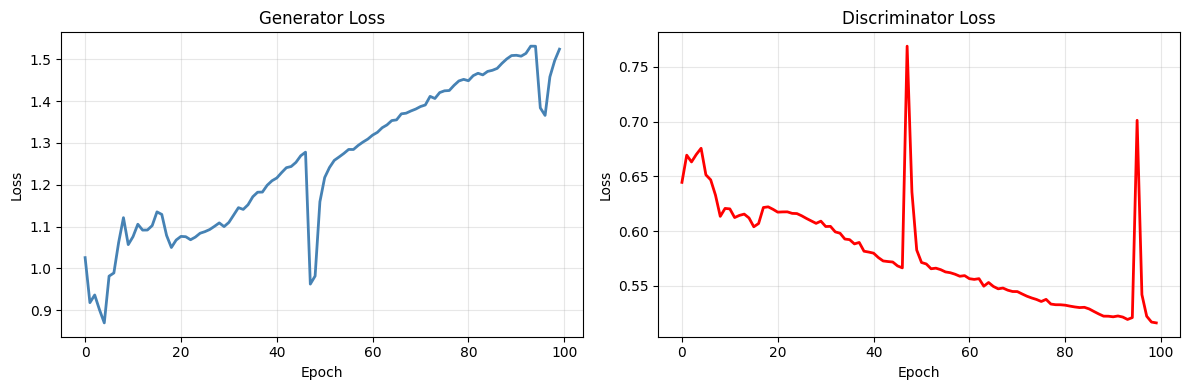

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['g_loss'], color='steelblue', linewidth=2)
plt.title('Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['d_loss'], color='red', linewidth=2)
plt.title('Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Example Images Generated from CGAN

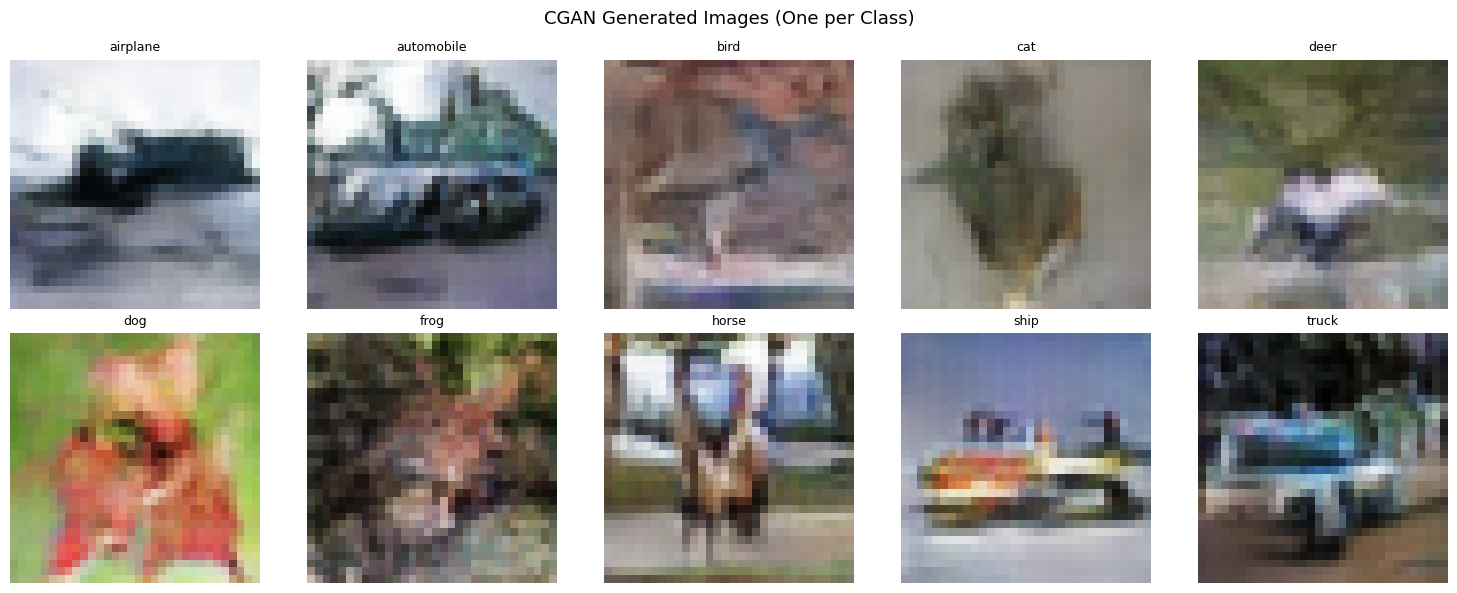

In [10]:
plt.figure(figsize=(15, 6))

for cls in range(num_classes):
    # Generate one image per class
    z = np.random.normal(size=(1, latent_dim)).astype('float32')
    label = np.zeros((1, num_classes), dtype='float32')
    label[0, cls] = 1.0

    gen_img = generator.predict([z, label], verbose=0)

    plt.subplot(2, 5, cls + 1)
    plt.imshow(np.clip(gen_img[0], 0, 1))
    plt.title(classes[cls], fontsize=9)
    plt.axis('off')

plt.suptitle('CGAN Generated Images (One per Class)', fontsize=13)
plt.tight_layout()
plt.show()

## Image Generation for Data Augmentation

In [11]:
def generate_images_gan(generator, n_per_class, latent_dim, num_classes):
    all_images = []
    all_labels = []

    for cls in range(num_classes):
        z = np.random.normal(size=(n_per_class, latent_dim)).astype('float32')
        y = np.zeros((n_per_class, num_classes), dtype='float32')
        y[:, cls] = 1.0

        generated = generator.predict([z, y], verbose=0)
        generated = np.clip(generated, 0, 1)

        all_images.append(generated)
        all_labels.append(y)

    return np.concatenate(all_images), np.concatenate(all_labels)

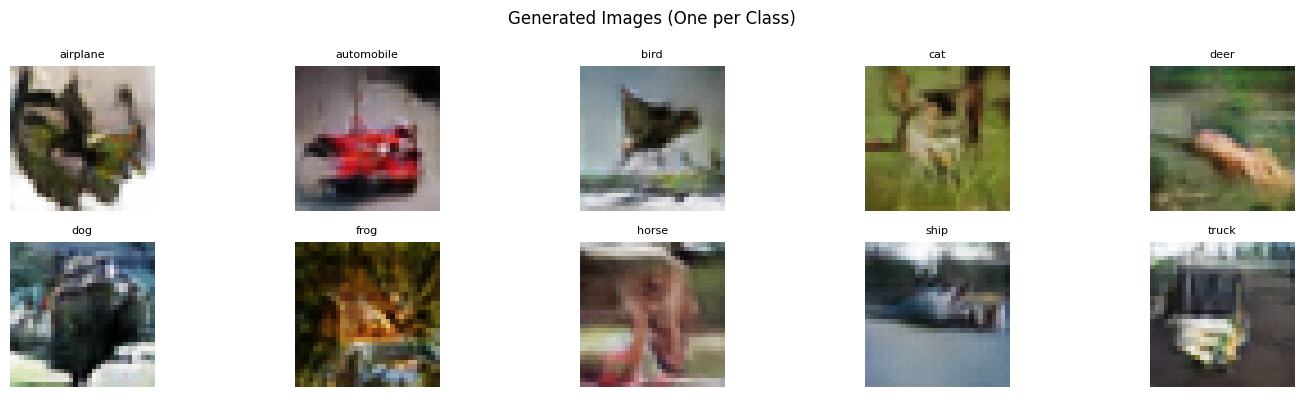

In [12]:
# Visualize a batch of generated images (10 per class)
gen_x, gen_y = generate_images_gan(generator, 10, latent_dim, num_classes)

plt.figure(figsize=(15, 4))

for cls in range(num_classes):
    class_indices = np.where(np.argmax(gen_y, axis=1) == cls)[0]
    idx = np.random.choice(class_indices)

    plt.subplot(2, 5, cls + 1)
    plt.imshow(gen_x[idx])
    plt.title(classes[cls], fontsize=8)
    plt.axis('off')

plt.suptitle('Generated Images (One per Class)')
plt.tight_layout()
plt.show()

## CNN Architecture

In [13]:
def build_cnn():
    inp = layers.Input((32, 32, 3))
    x   = layers.Conv2D(32, 3, strides=1, padding='same')(inp)
    x   = layers.BatchNormalization()(x)
    x   = layers.LeakyReLU()(x)
    x   = layers.Conv2D(32, 3, strides=2, padding='same')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.LeakyReLU()(x)
    x   = layers.Conv2D(64, 3, strides=1, padding='same')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.LeakyReLU()(x)
    x   = layers.Conv2D(64, 3, strides=2, padding='same')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.LeakyReLU()(x)
    x   = layers.Flatten()(x)
    x   = layers.Dense(128)(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.LeakyReLU()(x)
    x   = layers.Dropout(0.5)(x)
    out = layers.Dense(10, activation='softmax')(x)

    model = models.Model(inp, out)
    model.compile(
        loss='categorical_crossentropy',
        optimizer=optimizers.Adam(learning_rate=0.0005),
        metrics=['accuracy']
    )
    return model

### Validation Dataset Split

In [14]:
y_labels = np.argmax(y_train, axis=1)

x_train_cnn, x_val, y_train_cnn, y_val = train_test_split(
    x_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_labels
)

print(f"CNN Train: {x_train_cnn.shape}")
print(f"Val:       {x_val.shape}")

CNN Train: (45000, 32, 32, 3)
Val:       (5000, 32, 32, 3)


### Prepare Augmented Datasets (10, 50, 100 samples/class)

In [15]:
GEN_COUNTS = [10, 50, 100]

datasets = {}

# Baseline uses only the CNN training split
datasets[0] = (x_train_cnn.copy(), y_train_cnn.copy())

for n_gen in GEN_COUNTS:
    gen_x, gen_y = generate_images_gan(generator, n_gen, latent_dim, num_classes)

    x_aug = np.concatenate([x_train_cnn, gen_x], axis=0)
    y_aug = np.concatenate([y_train_cnn, gen_y], axis=0)

    # Shuffle
    idx = np.random.permutation(len(x_aug))
    x_aug = x_aug[idx]
    y_aug = y_aug[idx]

    datasets[n_gen] = (x_aug, y_aug)
    print(f"Aug +{n_gen}/class: {x_aug.shape[0]} total samples")

Aug +10/class: 45100 total samples
Aug +50/class: 45500 total samples
Aug +100/class: 46000 total samples


## CNN Training

In [16]:
histories    = {}
final_models = {}
labels_map   = {
    0:   'Baseline',
    10:  'GAN +10/class',
    50:  'GAN +50/class',
    100: 'GAN +100/class'
}

for n_gen, (x_tr, y_tr) in datasets.items():
    print(f"\n{'='*50}")
    print(f"Training: {labels_map[n_gen]}  |  {x_tr.shape[0]} samples")
    print(f"{'='*50}")

    model   = build_cnn()
    history = model.fit(
        x_tr, y_tr,
        validation_data=(x_val, y_val),
        epochs=30,
        batch_size=128,
        shuffle=True,
        verbose=1
    )

    histories[n_gen]    = history
    final_models[n_gen] = model


Training: Baseline  |  45000 samples
Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.3713 - loss: 1.8537 - val_accuracy: 0.2408 - val_loss: 2.1956
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5537 - loss: 1.2629 - val_accuracy: 0.5224 - val_loss: 1.3182
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6205 - loss: 1.0711 - val_accuracy: 0.5896 - val_loss: 1.1835
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6684 - loss: 0.9428 - val_accuracy: 0.6380 - val_loss: 1.0571
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6945 - loss: 0.8689 - val_accuracy: 0.6078 - val_loss: 1.1642
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7209 - loss: 0.7984 - val_accuracy: 0.6810 - val_loss: 0.9263
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7394 - loss: 0.7462 - val_accuracy: 0.6810 - val_loss: 0.9293
Epoch 8/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 

## Accuracy & Loss Trends over Epochs

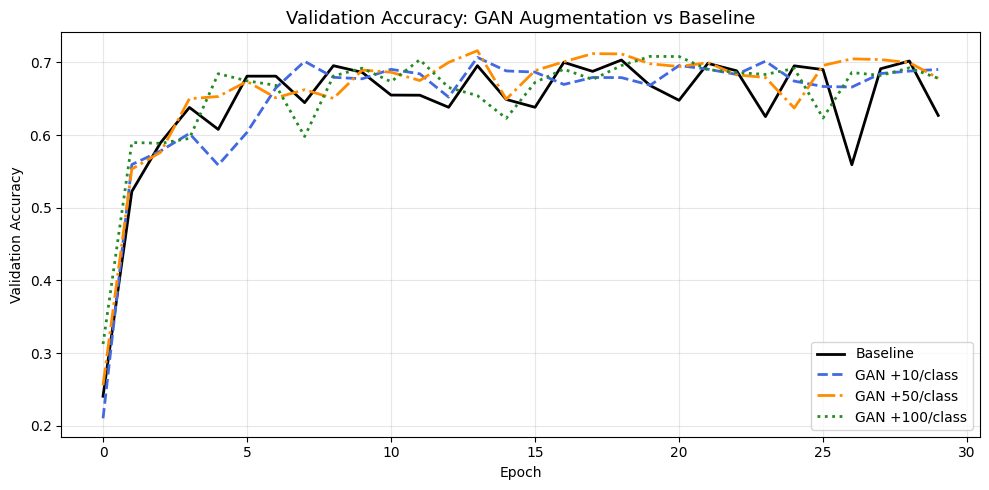

In [17]:
colors     = ['black', 'royalblue', 'darkorange', 'forestgreen']
linestyles = ['-', '--', '-.', ':']

plt.figure(figsize=(10, 5))
for (n_gen, history), color, ls in zip(histories.items(), colors, linestyles):
    plt.plot(
        history.history['val_accuracy'],
        label=labels_map[n_gen],
        color=color,
        linestyle=ls,
        linewidth=2
    )

plt.title('Validation Accuracy: GAN Augmentation vs Baseline', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/val_accuracy_comparison.png', dpi=150)
plt.show()

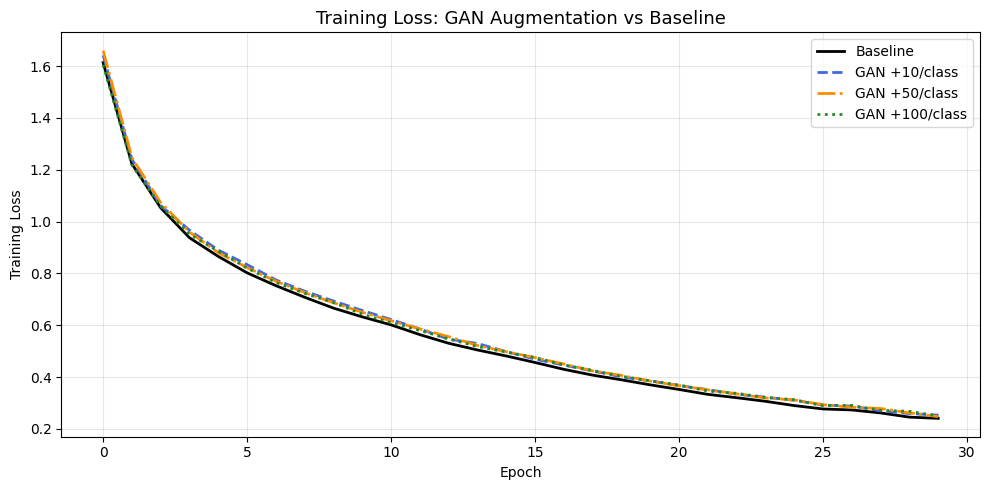

In [18]:
plt.figure(figsize=(10, 5))
for (n_gen, history), color, ls in zip(histories.items(), colors, linestyles):
    plt.plot(
        history.history['loss'],
        label=labels_map[n_gen],
        color=color,
        linestyle=ls,
        linewidth=2
    )

plt.title('Training Loss: GAN Augmentation vs Baseline', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/train_loss_comparison.png', dpi=150)
plt.show()

## Final Evaluation on Test Dataset

In [19]:
print(f"\n{'Model':<20} {'Test Accuracy':>15}")
print("-" * 36)

for n_gen, model in final_models.items():
    _, acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"{labels_map[n_gen]:<20} {acc:.4f}")


Model                  Test Accuracy
------------------------------------
Baseline             0.6402
GAN +10/class        0.6836
GAN +50/class        0.6670
GAN +100/class       0.6724


### Class-specific Metrics

In [20]:
for n_gen in [0, 10, 50, 100]:
    model  = final_models[n_gen]
    preds  = model.predict(x_test, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = np.argmax(y_test, axis=1)

    print(f"\n{'='*55}")
    print(f"  Classification Report — {labels_map[n_gen]}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred, target_names=classes))


  Classification Report — Baseline
              precision    recall  f1-score   support

    airplane       0.79      0.56      0.66      1000
  automobile       0.88      0.63      0.73      1000
        bird       0.49      0.60      0.54      1000
         cat       0.39      0.63      0.48      1000
        deer       0.76      0.38      0.50      1000
         dog       0.54      0.63      0.58      1000
        frog       0.77      0.69      0.73      1000
       horse       0.79      0.66      0.72      1000
        ship       0.85      0.73      0.79      1000
       truck       0.60      0.89      0.72      1000

    accuracy                           0.64     10000
   macro avg       0.69      0.64      0.65     10000
weighted avg       0.69      0.64      0.65     10000


  Classification Report — GAN +10/class
              precision    recall  f1-score   support

    airplane       0.77      0.65      0.70      1000
  automobile       0.80      0.80      0.80      1000
 

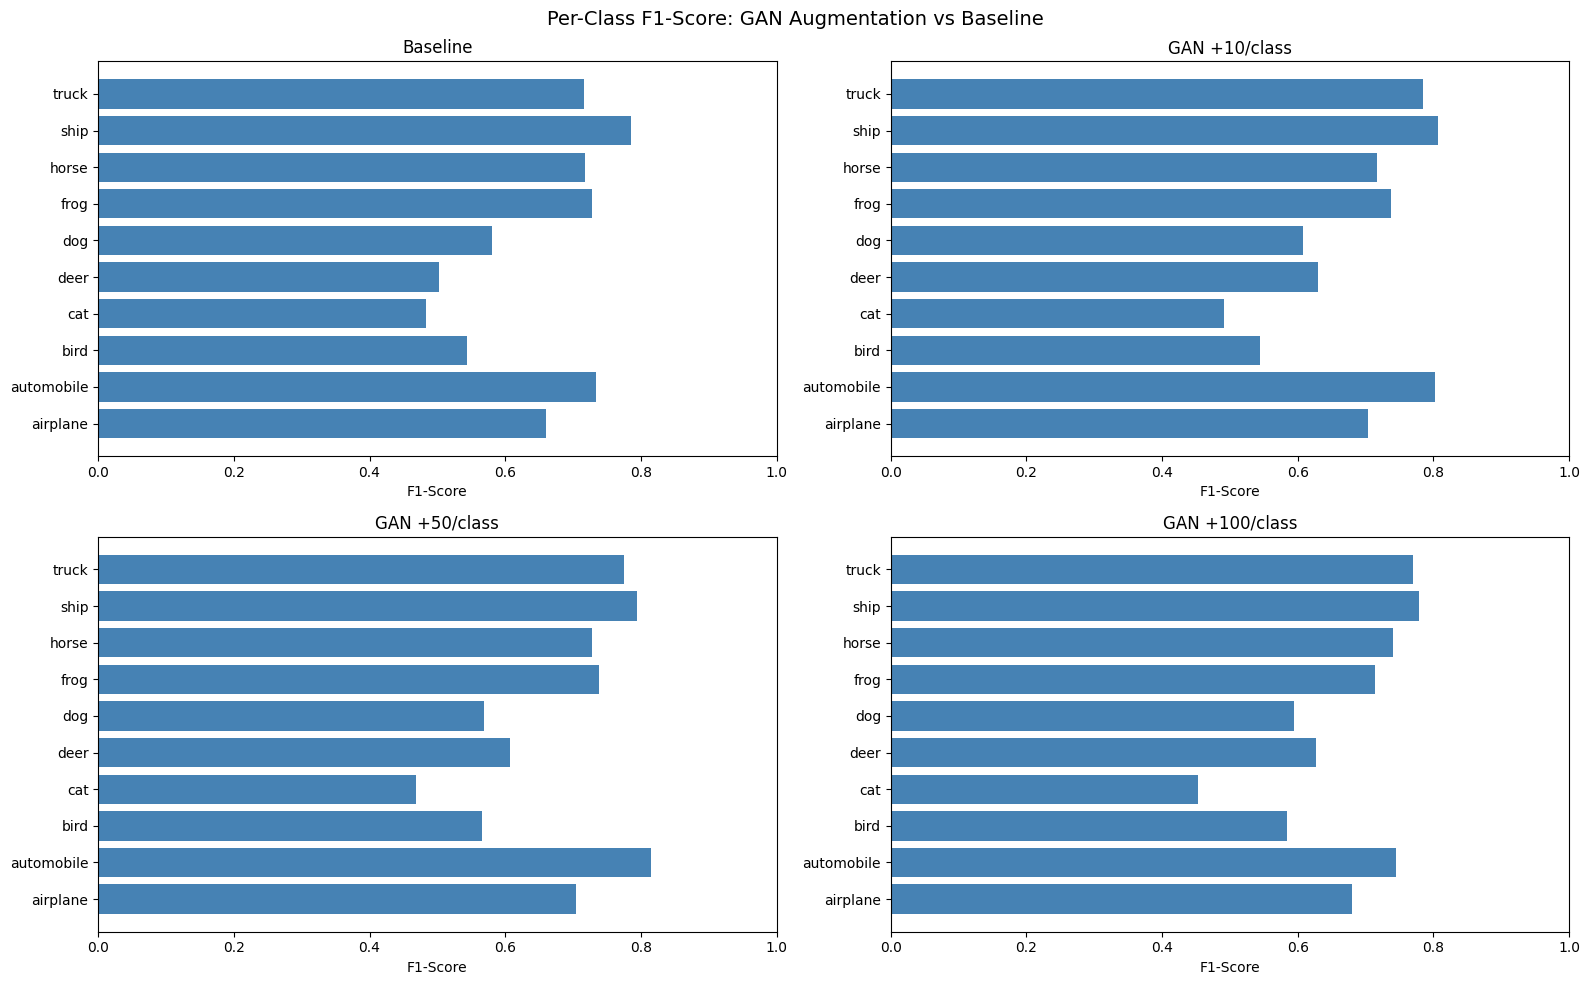

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, n_gen in zip(axes, [0, 10, 50, 100]):
    model  = final_models[n_gen]
    preds  = model.predict(x_test, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = np.argmax(y_test, axis=1)

    report    = classification_report(y_true, y_pred,
                                      target_names=classes,
                                      output_dict=True)
    f1_scores = [report[cls]['f1-score'] for cls in classes]

    ax.barh(classes, f1_scores, color='steelblue')
    ax.set_xlim(0, 1)
    ax.set_title(labels_map[n_gen], fontsize=12)
    ax.set_xlabel('F1-Score')

plt.suptitle('Per-Class F1-Score: GAN Augmentation vs Baseline', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/f1_per_class_comparison.png', dpi=150)
plt.show()

### Confusion Matrices

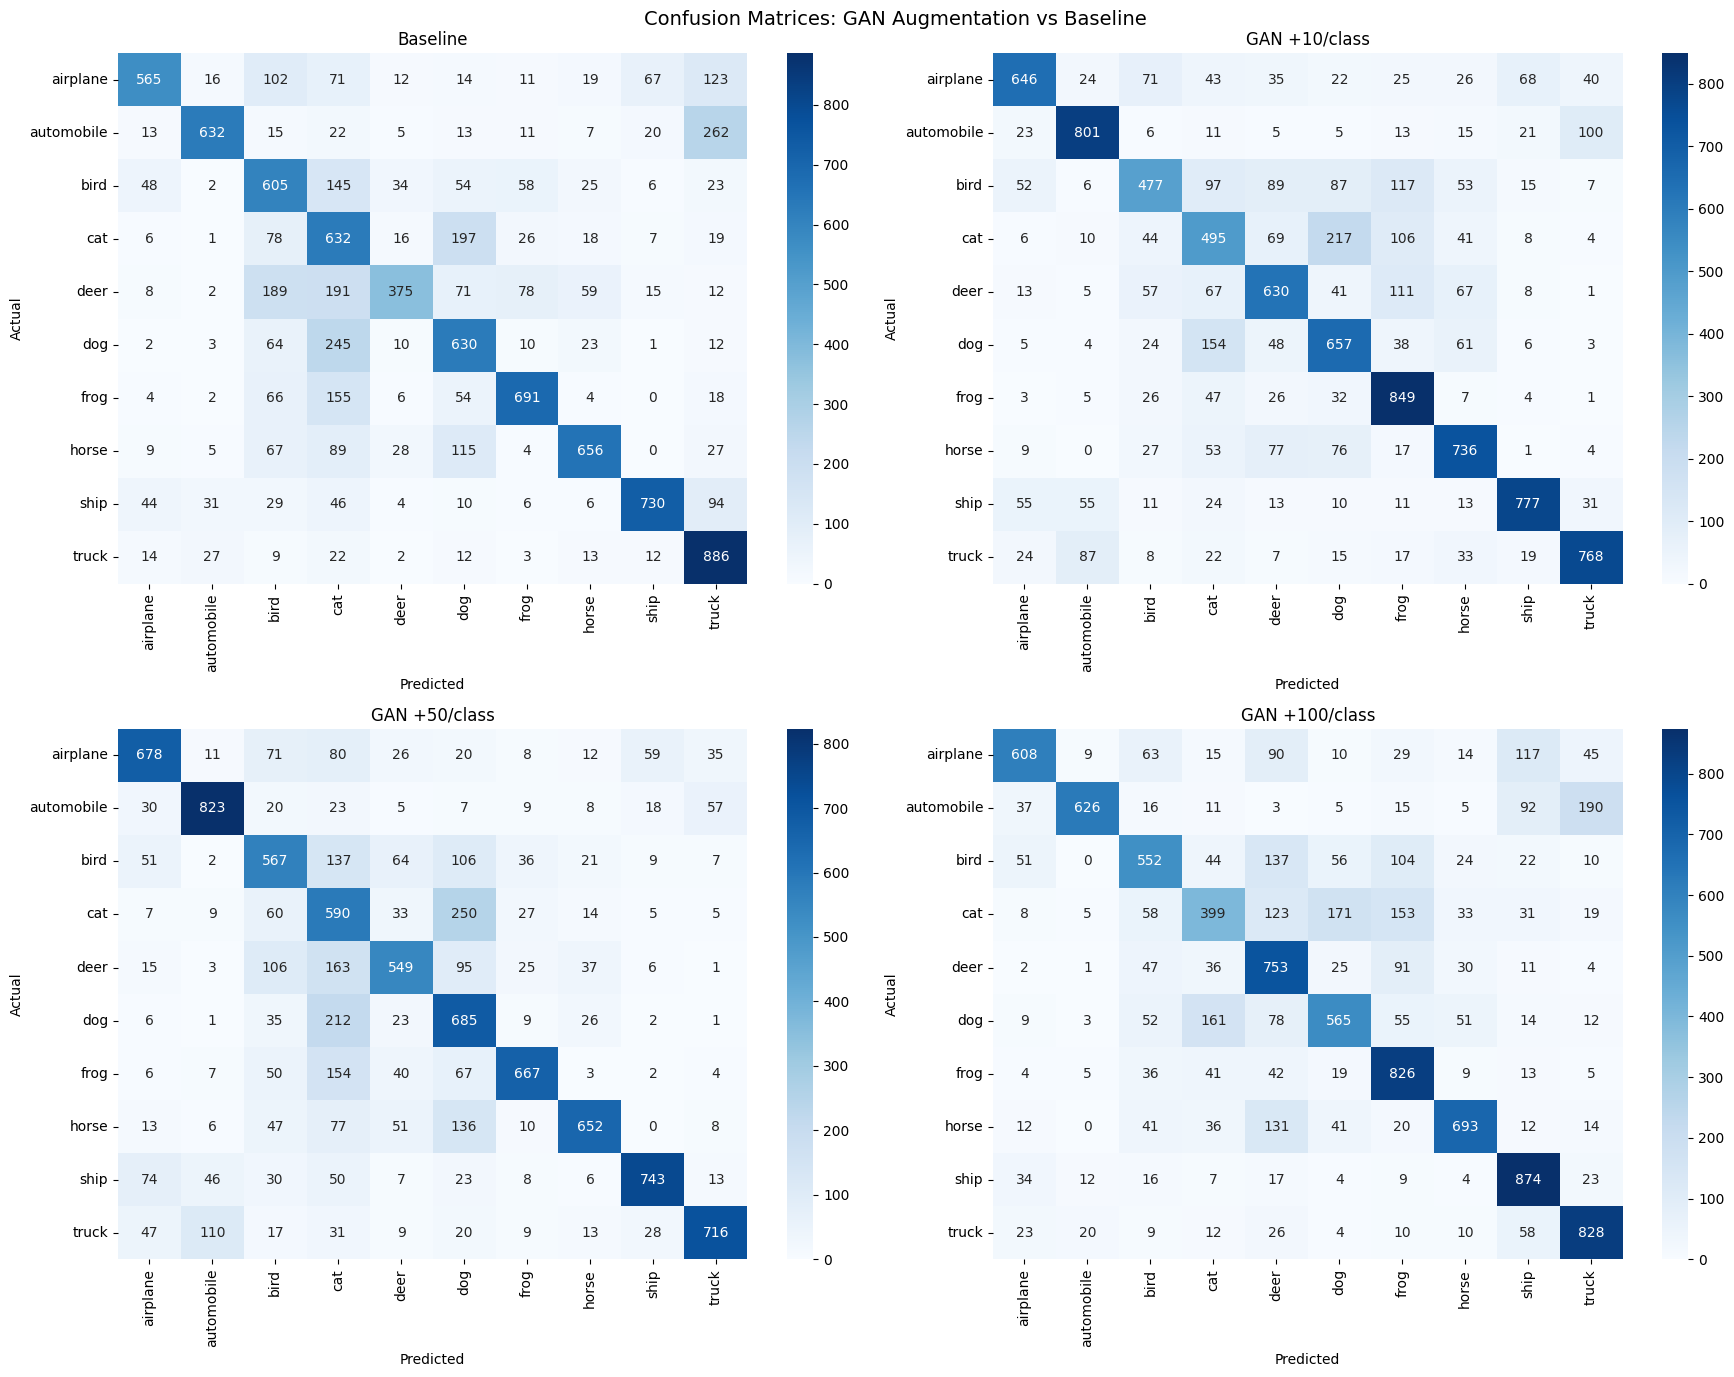

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, n_gen in zip(axes, [0, 10, 50, 100]):
    model  = final_models[n_gen]
    preds  = model.predict(x_test, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(labels_map[n_gen], fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices: GAN Augmentation vs Baseline', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrices.png', dpi=150)
plt.show()